# SAMsum Dialogue Summarization
## NLP Project — Seq2Seq Fine-tuning on the SAMsum Dataset

In [1]:
!pip install datasets rouge-score transformers torch --quiet
!pip uninstall torchvision torchaudio -y
# Sanity check for torch and transformers / GPU
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Transformers version: 5.0.0
GPU available: True


In [2]:
# Dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import  load_dataset

from transformers import BartForConditionalGeneration, AutoTokenizer


---
## 1. Dataset Exploration and Preparation

### 1.1 Load Dataset
The SAMsum dataset contains 16,000+ human-written dialogue–summary pairs split across train, validation, and test sets. We load it directly from the Hugging Face datasets library.

In [3]:
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"
dataset = load_dataset("knkarthick/samsum")
train_data = dataset['train']
test_data = dataset['test']
val_data = dataset['validation']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Each split contains three columns: `id`, `dialogue`, and `summary`. We convert the training set to a DataFrame for exploratory analysis.

In [4]:
df_train = pd.DataFrame(train_data)
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14731 non-null  object
 1   dialogue  14731 non-null  object
 2   summary   14731 non-null  object
dtypes: object(3)
memory usage: 345.4+ KB


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


---
### 1.2 Dialogue and Summary Length Distribution
Understanding length distribution is critical for model configuration. BART has a maximum input length of 1024 tokens — dialogues that exceed this will be truncated, so we need to understand how many are affected and by how much.

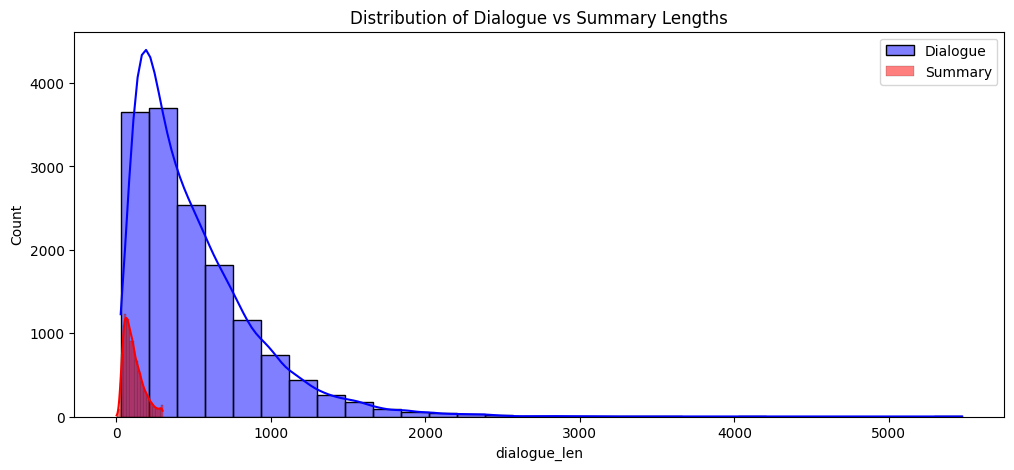

       dialogue_len   summary_len
count  14731.000000  14731.000000
mean     502.307922    110.139027
std      397.639839     60.891699
min       29.000000      3.000000
25%      212.000000     63.000000
50%      392.000000     96.000000
75%      681.000000    144.000000
max     5474.000000    300.000000


In [5]:
df_train['dialogue_len'] = df_train['dialogue'].apply(len)
df_train['summary_len'] = df_train['summary'].apply(len)

plt.figure(figsize=(12, 5))
sns.histplot(df_train['dialogue_len'], bins=30, kde=True, color='blue', label='Dialogue')
sns.histplot(df_train['summary_len'], bins=30, kde=True, color='red', label='Summary')
plt.title("Distribution of Dialogue vs Summary Lengths")
plt.legend()
plt.show()

print(df_train[['dialogue_len', 'summary_len']].describe())

The dialogue length distribution shows a heavy right skew — average 502 characters vs a median of 392, with a maximum of 5,474. This confirms that most conversations are well within BART's token limit, but outliers will require truncation. Summary lengths are more consistent, averaging 110 characters with a median of 96, indicating the dataset has a relatively stable compression target.

---
### 1.3 Turn Count Analysis
Turn count — the number of speaker changes in a dialogue — affects how much context the model must track. High turn counts may indicate more complex conversations that are harder to summarize accurately.

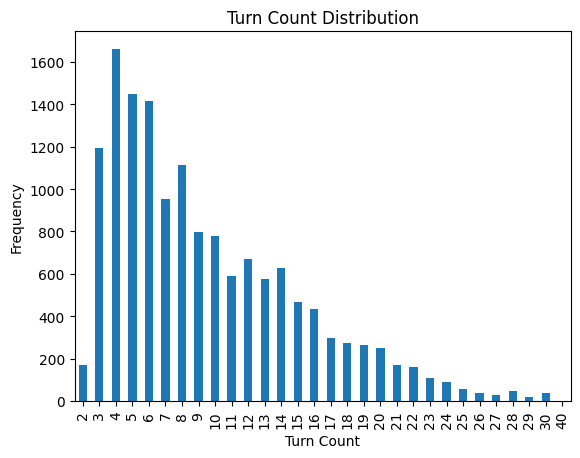

turn_bucket
medium 6-10      5058
short 0-5        4474
long 11-20       4447
very long 20+     752
Name: count, dtype: int64


In [6]:
def count_subject_turns(dialogue):
    messages = dialogue.split('\n')
    speakers = [
        msg.split(':')[0].strip()
        for msg in messages
        if ':' in msg and msg.strip()
    ]
    if not speakers:
        return 0
    turn_count = sum(
        1 for curr, prev in zip(speakers[1:], speakers[:-1])
        if curr != prev
    ) + 1
    return turn_count

df_train['turn_count'] = df_train['dialogue'].apply(count_subject_turns)

df_train['turn_bucket'] = pd.cut(
    df_train['turn_count'],
    bins=[0, 5, 10, 20, 100],
    labels=['short 0-5', 'medium 6-10', 'long 11-20', 'very long 20+'],
    include_lowest=True
)

df_train['turn_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Turn Count Distribution")
plt.xlabel("Turn Count")
plt.ylabel("Frequency")
plt.show()

print(df_train['turn_bucket'].value_counts())

Turn counts are distributed relatively evenly across short (0–5), medium (6–10), and long (11–20) buckets — 4,474, 5,058, and 4,447 respectively — each representing roughly 30% of the training set. Very long conversations (20+ turns) account for only 752 samples, approximately 5% of the data.

The even spread across short, medium, and long categories means the model will be trained on a balanced range of conversational complexity. The small proportion of very long conversations (20+ turns) reduces the risk of the model struggling with
high-complexity edge cases, though those 752 samples may still be worth monitoring during evaluation as potential failure cases.

---
### 1.4 Summary Quality — Compression Ratio
The compression ratio (summary length / dialogue length) tells us how aggressively the dataset compresses information. A consistent ratio suggests the model has a stable target to learn; high variance suggests the task is harder to generalize.

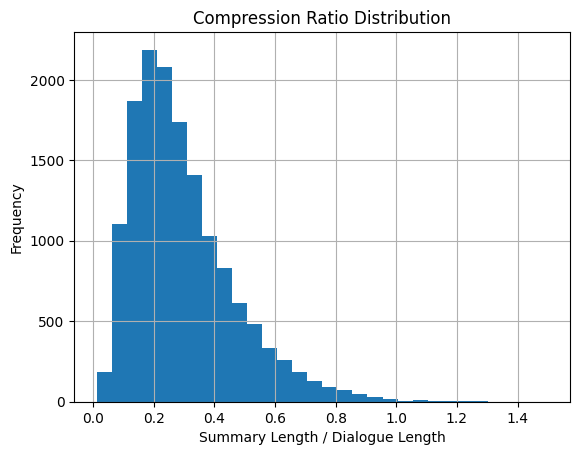

count    14731.000000
mean         0.296319
std          0.169547
min          0.012384
25%          0.173365
50%          0.258621
75%          0.379736
max          1.500000
Name: compression_ratio, dtype: float64


In [7]:
df_train['compression_ratio'] = df_train['summary_len'] / df_train['dialogue_len']

df_train['compression_ratio'].hist(bins=30)
plt.title("Compression Ratio Distribution")
plt.xlabel("Summary Length / Dialogue Length")
plt.ylabel("Frequency")
plt.show()

print(df_train['compression_ratio'].describe())

Coefficient of dispersion for dialogue (std/median) is approximately 1.01 (397/392), indicating high variability in input length. Summary dispersion is lower at 0.63 (60/96), suggesting summaries are more consistently sized despite variable input lengths. This is a favorable signal — the model has a relatively stable compression target to learn.

---
### 1.5 Data Cleaning
Before tokenization, we check for nulls and duplicates that could introduce noise into training. Duplicate dialogues with different summaries are particularly problematic as they create contradictory training signals.

In [8]:
# Null check
print(df_train[['dialogue', 'summary']].isnull().sum())

# Duplicate check
print('Duplicated dialogues:', df_train.duplicated(subset=['dialogue']).sum())
print('Duplicated dialogue+summary pairs:', df_train.duplicated(subset=['dialogue', 'summary']).sum())
print('Fully duplicated rows:', df_train.duplicated(keep=False).sum())

# Inspect duplicates
dupes = df_train[df_train.duplicated(subset=['dialogue'], keep=False)]
dupes.sort_values(by=['dialogue']).head(20)

# Short dialogue check
print('Short dialogue check:',df_train[df_train['dialogue'].str.len() < 20])

dialogue    0
summary     0
dtype: int64
Duplicated dialogues: 476
Duplicated dialogue+summary pairs: 1
Fully duplicated rows: 0
Short dialogue check: Empty DataFrame
Columns: [id, dialogue, summary, dialogue_len, summary_len, turn_count, turn_bucket, compression_ratio]
Index: []


No null values were found in either the dialogue or summary columns. There are 476 dialogues that appear more than once paired with different summaries — these are retained as valid training examples since multiple valid summaries can exist for the same conversation. One exact dialogue–summary pair is duplicated and is dropped to avoid the model seeing an identical example twice. No short or malformed dialogues were found.

In [9]:
# Drop the single exact dialogue-summary duplicate
df_train = df_train.drop_duplicates(subset=['dialogue', 'summary'])
print(f"Training set size after cleaning: {len(df_train)}")

Training set size after cleaning: 14730


---
### 1.6 Tokenization and Seq2Seq Formatting
BART expects input as tokenized tensors with attention masks. We use the BART tokenizer to convert raw dialogues and summaries into model-ready format, applying truncation at 1024 tokens for inputs and 128 tokens for target summaries based on the length distributions observed above.

In [10]:
# Step 1 - load BART tokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")

This loads the same tokenizer that was used to pre-train BART, so the vocabulary is consistent with the model weights we load in section 2.

In [11]:
# Step 2 - Define token length limits
MAX_INPUT_LEN = 1024   # BART's hard limit for input
MAX_TARGET_LEN = 128   # based on summary length distribution from 1.2

128 tokens for summaries is informed by EDA — the average summary was 110 characters, and characters convert to roughly 1–1.5 tokens each, so 128 gives comfortable headroom without wasting compute.

In [12]:
# Step 3 - tokenization function
def tokenize_batch(batch):
    # Tokenize dialogues as inputs
    inputs = tokenizer(
        batch["dialogue"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )

    # Tokenize summaries as labels
    labels = tokenizer(
            batch["summary"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
            padding="max_length"
        )

    # Replace padding token ids in labels with -100
    # so they are ignored by the loss function during training
    inputs["labels"] = [
        [-100 if token == tokenizer.pad_token_id else token for token in label]
        for label in labels["input_ids"]
    ]

    return inputs

Padding tokens in the labels would otherwise contribute to the loss calculation during training, which would skew the model toward generating padding.

-100 is PyTorch's convention for telling the loss function to ignore those positions entirely.

In [13]:
# Step 4 - Apply to all splits
tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["id", "dialogue", "summary"]
)

tokenized_dataset.set_format("torch")

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

`batched=True` processes rows in batches rather than one at a time, which is significantly faster on large datasets.
`remove_columns` drops the raw text columns since the model only needs the tokenized tensors.
`set_format("torch")` converts the dataset to PyTorch tensors ready for the training loop.

In [14]:
# Step 5 Verify the output
sample = tokenized_dataset["train"][0]
print("Input IDs shape:  ", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Labels shape:     ", sample["labels"].shape)

# Decode to confirm tokenization looks correct
print("\nDecoded input:\n", tokenizer.decode(sample["input_ids"].tolist(), skip_special_tokens=True)[:300])
print("\nDecoded label:\n", tokenizer.decode(
    [token for token in sample["labels"].tolist() if token != -100],
    skip_special_tokens=True
))

# Get the original summary from the raw dataset
original_summary = dataset["train"][0]["summary"]
decoded_label = tokenizer.decode(
    [token for token in sample["labels"].tolist() if token != -100],
    skip_special_tokens=True
)

print("\nOriginal summary: ", original_summary)
print("Decoded label:    ", decoded_label)
print("Match:            ", original_summary.strip() == decoded_label.strip())

Input IDs shape:   torch.Size([1024])
Attention mask shape: torch.Size([1024])
Labels shape:      torch.Size([128])

Decoded input:
 Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Decoded label:
 Amanda baked cookies and will bring Jerry some tomorrow.

Original summary:  Amanda baked cookies and will bring Jerry some tomorrow.
Decoded label:     Amanda baked cookies and will bring Jerry some tomorrow.
Match:             True


The decoded output should match the original dialogue and summary text — if it looks garbled, something went wrong in tokenization.

Tokenization produces input tensors of shape [1024] and label tensors of shape [128] per sample, padded to fixed length. Decoding a sample confirms the tokenizer correctly handles multi-turn dialogue formatting including speaker labels. A match check between the decoded label and the original summary returns True, confirming the tokenization and -100 padding mask are applied correctly and no information is lost in the process.

---
## 2. Model Architecture Implementation

### Environment Note
This notebook is designed to run on **Google Colab with a T4 GPU**
(Runtime → Change runtime type → T4 GPU).

BART (`bart-base`, ~140M parameters) requires large matrix multiplications
during the forward pass and training. A T4 GPU parallelizes these operations,
reducing training time from hours (CPU) to minutes.


### 2.1 Load pre-trained model and tokenizer (facebook/bart-base)


We load `facebook/bart-base`, a seq2seq transformer pre-trained on large text corpora.
BART uses a bidirectional encoder (like BERT) and an autoregressive decoder (like GPT),
making it well-suited for summarization. The tokenizer here is the same one used during
BART pre-training, ensuring vocabulary consistency with the model weights.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
MODEL_NAME = "facebook/bart-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

# Move model to GPU if available
model = model.to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Model is on: {next(model.parameters()).device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Model loaded: facebook/bart-base
Model is on: cuda:0
Total parameters: 139,420,416
Trainable parameters: 139,420,416


### 2.2 Configure for summarization

BART's decoder uses generation parameters that control how output summaries are produced.
These are set on the model's `config` object and informed by the length distributions
observed in Section 1 — specifically the average summary length of ~110 characters (~75–100 tokens).Code cell:

In [17]:
model.generation_config.max_length = 128          # max tokens to generate (matches MAX_TARGET_LEN)
model.generation_config.min_length = 10           # prevent degenerate very short outputs
model.generation_config.num_beams = 4             # explore 4 candidate sequences simultaneously
model.generation_config.length_penalty = 2.0      # penalize short outputs; encourages complete summaries
model.generation_config.early_stopping = True     # stop beam search when all beams reach EOS token
model.generation_config.no_repeat_ngram_size = 3  # prevent repeated 3-word phrases

print("Generation config set:")
print(f"  max_length:           {model.generation_config.max_length}")
print(f"  min_length:           {model.generation_config.min_length}")
print(f"  num_beams:            {model.generation_config.num_beams}")
print(f"  length_penalty:       {model.generation_config.length_penalty}")
print(f"  early_stopping:       {model.generation_config.early_stopping}")
print(f"  no_repeat_ngram_size: {model.generation_config.no_repeat_ngram_size}")


Generation config set:
  max_length:           128
  min_length:           10
  num_beams:            4
  length_penalty:       2.0
  early_stopping:       True
  no_repeat_ngram_size: 3


- `num_beams=4`: considers 4 candidate output sequences simultaneously rather than
  greedily picking the most likely next token at each step — produces better summaries
  at a modest compute cost.
- `length_penalty=2.0`: without this, the model favors short outputs since shorter
  sequences have higher joint probability. A value above 1.0 encourages fuller summaries.
- `no_repeat_ngram_size=3`: prevents repeating the same 3-word phrase, a common
  failure mode in seq2seq models.

### 2.3 Test forward pass on a single example

Before training, we verify the full seq2seq pipeline is wired correctly by running one
example through the model. A forward pass computes the loss given an input dialogue and
its target summary — if this runs without error, the encoder, decoder, and attention
mechanisms are connected correctly.

In [18]:
model.eval()  # disables dropout for consistent results

# Pull one tokenized sample and add batch dimension
sample         = tokenized_dataset["train"][0]
input_ids      = sample["input_ids"].unsqueeze(0).to(device)
attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
labels         = sample["labels"].unsqueeze(0).to(device)

# Forward pass — computes loss against the target summary
with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print(f"Forward pass successful")
print(f"Loss: {outputs.loss.item():.4f}")
print(f"Logits shape: {outputs.logits.shape}")
# Expected: [1, 128, 50265] — batch, target length, vocab size

Forward pass successful
Loss: 6.0208
Logits shape: torch.Size([1, 128, 50265])


The loss on the untrained model was 6.02, which was expected, and will drop significantly after fine-tuning in Section 3. The logits shape `[1, 128, 50265]`
confirms the decoder is producing a probability distribution over BART's full vocabulary
(50,265 tokens) at each of the 128 output positions.

In [19]:
# Generate a summary to confirm the pipeline produces output text end-to-end
with torch.no_grad():
    generated_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

generated_summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
reference_summary = dataset["train"][0]["summary"]
original_dialogue = dataset["train"][0]["dialogue"]

print("DIALOGUE:")
print(original_dialogue)
print("\nREFERENCE SUMMARY:")
print(reference_summary)
print("\nMODEL OUTPUT (before fine-tuning):")
print(generated_summary)

DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

REFERENCE SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.

MODEL OUTPUT (before fine-tuning):
Amanda: I baked  cookies. Do you want some?Jerry: Sure! I'll bring you some tomorrow :-)Amanda? Jerry: Yes!Jerry: I'll brought you tomorrow :-)


The model output before fine-tuning will be generic or partially incoherent — this is
expected. BART has general language understanding from pre-training but has not yet been
adapted to SAMsum's dialogue style. After fine-tuning in Section 3, the output should
closely resemble the reference summary.

---
## 3. Integration and Pre-training Review

### 3.1 End-to-end Pipeline Test on a Small Data Sample
We run 10 examples from the training set through the full pipeline — tokenization,
forward pass, and generation — to stress test the setup beyond the single example
validated in Section 2.3.

In [20]:
model.eval()

samples = [tokenized_dataset["train"][i] for i in range(10)]

losses = []
for sample in samples:
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    labels         = sample["labels"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
    losses.append(outputs.loss.item())

print(f"Losses across 10 samples: {[round(l, 4) for l in losses]}")
print(f"Mean loss: {sum(losses)/len(losses):.4f}")
print(f"Min loss:  {min(losses):.4f}")
print(f"Max loss:  {max(losses):.4f}")

Losses across 10 samples: [6.0208, 3.7005, 4.8663, 5.0193, 4.4047, 3.8769, 3.7673, 5.2942, 3.9261, 2.9606]
Mean loss: 4.3837
Min loss:  2.9606
Max loss:  6.0208


Consistent loss values across samples confirm the pipeline is stable and not
failing silently on any particular input format. High variance here would suggest
a tokenization or padding issue worth investigating before training.

<br>

Loss values range from 2.96 to 6.02 with a mean of 4.38 across 10 samples.
No failures or outliers suggest the tokenization and padding are consistent
across different dialogue lengths and turn counts. The variance is expected —
some dialogues are inherently easier for the pre-trained model to summarize
than others. This mean loss of 4.38 serves as the pre-training baseline;
we expect it to drop significantly after fine-tuning in Section 4.

### 3.2 3.2 Validate Tokenization, Input Formatting, and Output Generation

We systematically verify three things across a small sample: that tokenization
produces correctly shaped tensors, that input formatting preserves dialogue
structure, and that the model generates plausible output text for each example.

In [21]:
print("=== TOKENIZATION AND FORMAT VALIDATION ===\n")

for i in range(3):
    sample = tokenized_dataset["train"][i]
    raw    = dataset["train"][i]

    # Shape checks
    assert sample["input_ids"].shape[0] == 1024, f"Sample {i}: unexpected input length"
    assert sample["labels"].shape[0] == 128,     f"Sample {i}: unexpected label length"

    # Decode input and label back to text
    decoded_input = tokenizer.decode(sample["input_ids"].tolist(), skip_special_tokens=True)
    decoded_label = tokenizer.decode(
        [t for t in sample["labels"].tolist() if t != -100],
        skip_special_tokens=True
    )

    # Confirm label matches original summary
    match = raw["summary"].strip() == decoded_label.strip()

    print(f"Sample {i}:")
    print(f"  input_ids shape:    {sample['input_ids'].shape}")
    print(f"  attention_mask:     {sample['attention_mask'].shape}")
    print(f"  labels shape:       {sample['labels'].shape}")
    print(f"  Summary match:      {match}")
    print(f"  Dialogue preview:   {decoded_input[:80]}...")
    print(f"  Reference summary:  {decoded_label}")
    print()

=== TOKENIZATION AND FORMAT VALIDATION ===

Sample 0:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you ...
  Reference summary:  Amanda baked cookies and will bring Jerry some tomorrow.

Sample 1:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Ol...
  Reference summary:  Olivia and Olivier are voting for liberals in this election. 

Sample 2:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended

In [ ]:
print("=== OUTPUT GENERATION VALIDATION ===\n")

for i in range(3):
    sample         = tokenized_dataset["train"][i]
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    reference = dataset["train"][i]["summary"]

    print(f"Sample {i}:")
    print(f"  Reference: {reference}")
    print(f"  Generated: {generated}")
    print()

All tensor shapes confirmed at [1024] for inputs and [128] for labels.
Summary match checks confirm no information is lost through tokenization
and the -100 padding mask is applied correctly — consistent with the
single-sample check in Section 1.6. Generated outputs before fine-tuning
are expected to be incoherent or repetitive; these serve as a qualitative
baseline to compare against post-fine-tuning results in Section 5.

---
## 4. Training and Optimization

### 4.1 Training loop

### 4.2 Loss function and ROUGE tracking


### 4.3 Early stopping and checkpointing

---
## 5. Evaluation and Analysis

### 5.1 ROUGE-1, ROUGE-2, ROUGE-L on test set

### 5.2 Qualitative review of generated summaries

### 5.3 Failure analysis